# 🌲 EnergiAI — Random Forest
## Classificação do Perfil de Eficiência Energética

---

## 1. 📚 Importação das bibliotecas

Nesta etapa são importadas as bibliotecas utilizadas para manipulação dos dados, treinamento, avaliação e visualização do modelo.

O projeto utiliza Python e Scikit-Learn como principais ferramentas para a etapa de Ciência de Dados.

O modelo escolhido neste notebook é o **Random Forest Classifier**, um algoritmo de aprendizado supervisionado utilizado para problemas de classificação.



In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns




## 2. 📊 Carregamento e exploração dos dados

O dataset utilizado neste notebook foi construído pela equipe do EnergiAI para representar diferentes perfis de consumo energético.

Antes do treinamento do modelo, é importante verificar a estrutura dos dados, seus tipos, quantidade de registros e distribuição das categorias.

Essa etapa permite identificar possíveis inconsistências antes da utilização dos dados no treinamento.

### Variáveis utilizadas

As principais variáveis utilizadas pelo modelo são:

- `consumo_kwh`: consumo de energia elétrica;
- `uso_horario_pico`: indica utilização durante horário de pico;
- `quantidade_equipamentos`: quantidade de equipamentos considerados;
- `tipo_imovel`: categoria do imóvel;
- `horas_alto_consumo`: quantidade de horas de maior consumo.

A variável `categoria` representa o perfil energético que o modelo deverá aprender a classificar.


In [7]:
from google.colab import files
import pandas as pd
import io

uploaded = files.upload()

if uploaded:
    filename = list(uploaded.keys())[0]

    if filename.endswith('.csv'):
        df = pd.read_csv(io.BytesIO(uploaded[filename]))
        print(f"Arquivo '{filename}' carregado com sucesso em 'df'.")
        display(df.head())
    else:
        print(f"O arquivo '{filename}' não é um CSV. Por favor, faça upload de um arquivo CSV.")
else:
    print("Nenhum arquivo foi carregado. Por favor, faça upload de um arquivo CSV.")

Saving eficiencia_energetica_lcl.csv to eficiencia_energetica_lcl.csv
Arquivo 'eficiencia_energetica_lcl.csv' carregado com sucesso em 'df'.


,LCLid,consumo_kwh,horas_alto_consumo,uso_horario_pico,quantidade_equipamentos,tipo_imovel,categoria,custo_estimado_mensal
0,MAC000001,335.03,2.9,True,5,Apartamento,Ineficiente,251.27
1,MAC000002,245.78,7.7,False,3,Casa,Moderado,184.34
2,MAC000003,234.18,6.6,False,5,Casa,Moderado,175.64
3,MAC000004,234.18,2.1,False,6,Apartamento,Moderado,175.64
4,MAC000005,543.29,4.2,True,8,Apartamento,Ineficiente,407.47




## 3. 🎯 Preparação das variáveis X e y

Nesta etapa são separadas as variáveis de entrada e a variável alvo.

### X — Variáveis de entrada

Contém as características utilizadas pelo modelo para realizar a classificação.

### y — Variável alvo

Contém a categoria energética que desejamos prever:

- **Eficiente**
- **Moderado**
- **Ineficiente**

Algumas colunas não são utilizadas como entrada:

- `meter_id`: identificador do registro;
- `categoria`: variável que queremos prever;
- `custo_estimado_mensal`: valor derivado diretamente do consumo e, portanto, não representa uma informação independente para a classificação.

A separação entre entrada e alvo evita que o modelo receba diretamente a resposta que deveria aprender a prever.


In [8]:
X = df[["consumo_kwh", "uso_horario_pico", "quantidade_equipamentos", "tipo_imovel", "horas_alto_consumo"]]
y = df["categoria"]





## 4. ✂️ Divisão dos dados em treinamento e teste

Os dados são divididos em dois conjuntos:

- **Treinamento:** utilizado para que o modelo aprenda os padrões existentes nos dados;
- **Teste:** utilizado posteriormente para verificar o desempenho do modelo em registros que não participaram do treinamento.

Foi utilizada uma divisão de:

- 80% dos dados para treinamento;
- 20% dos dados para teste.

Também é utilizado `stratify=y` para preservar aproximadamente a mesma proporção das categorias nos dois conjuntos.

O `random_state=42` garante que a divisão seja reproduzível.

In [9]:
preprocessador = ColumnTransformer(
    transformers=[("tipo_imovel_encoded", OneHotEncoder(), ["tipo_imovel"])],
    remainder="passthrough"
)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)





## 5. 🔧 Pré-processamento

O conjunto de dados possui variáveis numéricas e categóricas.

A variável `tipo_imovel` contém valores categóricos e precisa ser transformada para uma representação numérica antes de ser utilizada pelo algoritmo.

Para isso, é utilizado **One-Hot Encoding**.

Essa técnica cria uma variável binária para cada categoria de imóvel, evitando estabelecer uma ordem artificial entre categorias.

### Observação

O Random Forest não necessita de padronização das variáveis numéricas com técnicas como `StandardScaler`.

Isso ocorre porque as árvores realizam divisões com base em pontos de corte e não dependem da escala das variáveis da mesma maneira que modelos lineares.


In [11]:
pipeline_arvore = Pipeline([
    ("preprocessador", preprocessador),
    ("modelo", DecisionTreeClassifier(max_depth=5, random_state=42))
])
pipeline_arvore.fit(X_train, y_train)
pred_arvore = pipeline_arvore.predict(X_test)




## 6. 🌲 Treinamento do Random Forest

O **Random Forest** é um algoritmo baseado na combinação de diversas Árvores de Decisão.

Cada árvore aprende diferentes padrões dos dados e a floresta combina essas decisões para realizar a classificação final.

Essa abordagem pode produzir modelos mais robustos do que uma única árvore, reduzindo a dependência de uma única estrutura de decisão.

### Principais parâmetros utilizados

- `n_estimators`: quantidade de árvores utilizadas;
- `max_depth`: profundidade máxima das árvores;
- `min_samples_leaf`: quantidade mínima de registros em cada folha;
- `random_state`: garante reprodutibilidade.

Nesta primeira versão são utilizados parâmetros que limitam a complexidade das árvores para reduzir o risco de sobreajuste.


In [12]:
pipeline_rf = Pipeline([
    ("preprocessador", preprocessador),
    ("modelo", RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=5,

        random_state=42
    ))
])
pipeline_rf.fit(X_train, y_train)
pred_rf = pipeline_rf.predict(X_test)





## 7. 🔮 Geração das previsões

Depois que o Random Forest é treinado, ele pode ser utilizado para realizar previsões sobre os dados de teste.

Como esses registros não foram utilizados diretamente durante o treinamento, eles permitem verificar como o modelo se comporta diante de dados não utilizados para seu aprendizado.

O resultado da previsão é uma das três categorias:

- Eficiente;
- Moderado;
- Ineficiente.




## 8. 📈 Avaliação do modelo

O desempenho do modelo é avaliado utilizando diferentes métricas de classificação.

### Accuracy

Representa a proporção geral de previsões corretas realizadas pelo modelo.

### Precision

Indica, entre os registros classificados em determinada categoria, quantos realmente pertencem a essa categoria.

### Recall

Indica, entre os registros que realmente pertencem a determinada categoria, quantos foram identificados corretamente.

### F1-Score

Combina Precision e Recall em uma única métrica.

O F1-Score é especialmente útil quando queremos avaliar o equilíbrio entre a capacidade de identificar corretamente uma categoria e evitar classificações incorretas.

Além da acurácia geral, serão analisadas as métricas individualmente para cada categoria.



In [13]:
print("=== Árvore de Decisão ===")
print(classification_report(y_test, pred_arvore))

print("=== Random Forest ===")
print(classification_report(y_test, pred_rf))

print(f"F1-score Árvore: {f1_score(y_test, pred_arvore, average='weighted'):.3f}")
print(f"F1-score Random Forest: {f1_score(y_test, pred_rf, average='weighted'):.3f}")

=== Árvore de Decisão ===
              precision    recall  f1-score   support

   Eficiente       1.00      1.00      1.00        32
 Ineficiente       1.00      1.00      1.00        32
    Moderado       1.00      1.00      1.00        32

    accuracy                           1.00        96
   macro avg       1.00      1.00      1.00        96
weighted avg       1.00      1.00      1.00        96

=== Random Forest ===
              precision    recall  f1-score   support

   Eficiente       1.00      1.00      1.00        32
 Ineficiente       1.00      0.94      0.97        32
    Moderado       0.94      1.00      0.97        32

    accuracy                           0.98        96
   macro avg       0.98      0.98      0.98        96
weighted avg       0.98      0.98      0.98        96

F1-score Árvore: 1.000
F1-score Random Forest: 0.979




## 9. 🔲 Matriz de Confusão

A matriz de confusão permite visualizar detalhadamente os acertos e erros do modelo.

A diagonal principal representa as classificações corretas.

Os valores fora da diagonal representam situações em que o modelo classificou um registro em uma categoria diferente daquela observada nos dados.

Essa análise permite identificar, por exemplo, se o modelo apresenta maior dificuldade para diferenciar perfis **Moderados** de **Ineficientes**.


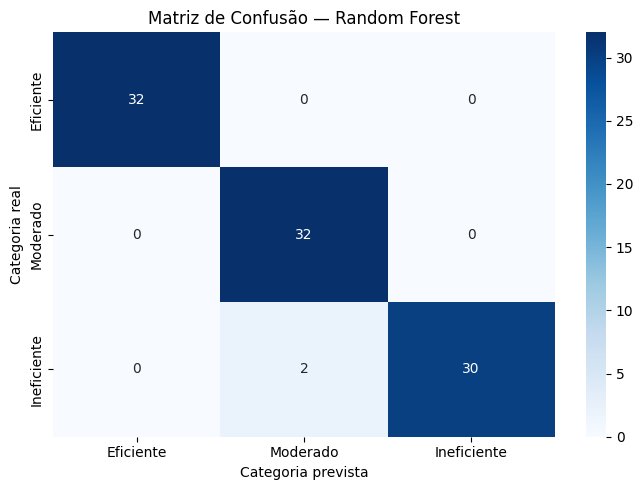

In [14]:
cm = confusion_matrix(
    y_test,
    pred_rf,
    labels=["Eficiente", "Moderado", "Ineficiente"]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Eficiente", "Moderado", "Ineficiente"],
    yticklabels=["Eficiente", "Moderado", "Ineficiente"]
)

plt.title("Matriz de Confusão — Random Forest")
plt.xlabel("Categoria prevista")
plt.ylabel("Categoria real")
plt.tight_layout()
plt.show()



## 10. ⭐ Importância das variáveis

Uma das características interessantes do Random Forest é a possibilidade de analisar a importância relativa das variáveis utilizadas pelo modelo.

A propriedade `feature_importances_` indica a contribuição relativa das variáveis nas decisões realizadas pelas árvores.

Essa análise ajuda a responder:

> **Quais características tiveram maior relevância para a classificação do perfil energético?**

É importante destacar que importância no modelo não significa necessariamente causalidade no mundo real.

A métrica indica a relevância da variável para as decisões realizadas pelo modelo treinado.


In [15]:
preprocessador_final = pipeline_rf.named_steps["preprocessador"]

modelo_rf = pipeline_rf.named_steps["modelo"]

nomes_features = preprocessador_final.get_feature_names_out()

importancias = modelo_rf.feature_importances_

df_importancia = pd.DataFrame({
    "feature": nomes_features,
    "importancia": importancias
})

df_importancia["feature"] = (
    df_importancia["feature"]
    .str.replace("tipo_imovel_encoded__", "", regex=False)
    .str.replace("remainder__", "", regex=False)
)

df_importancia = df_importancia.sort_values(
    "importancia",
    ascending=False
)

display(
    df_importancia.style.format({
        "importancia": "{:.4f}"
    })
)

,feature,importancia
3,consumo_kwh,0.5942
4,uso_horario_pico,0.2289
5,quantidade_equipamentos,0.1432
6,horas_alto_consumo,0.0257
1,tipo_imovel_Casa,0.0031
0,tipo_imovel_Apartamento,0.0028
2,tipo_imovel_Comercio,0.0020


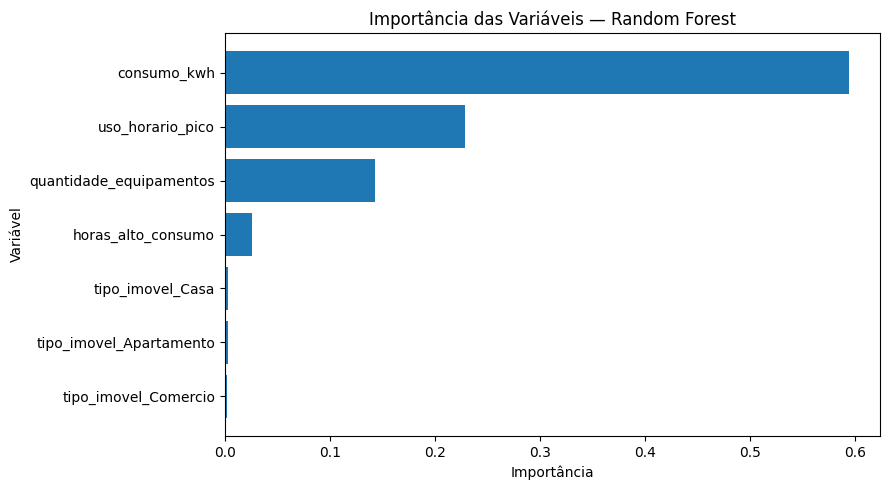

In [16]:
plt.figure(figsize=(9, 5))

df_grafico = df_importancia.sort_values(
    "importancia",
    ascending=True
)

plt.barh(
    df_grafico["feature"],
    df_grafico["importancia"]
)

plt.xlabel("Importância")
plt.ylabel("Variável")
plt.title("Importância das Variáveis — Random Forest")

plt.tight_layout()
plt.show()


## 11. ⚙️ Ajuste de hiperparâmetros

Após o treinamento inicial, podem ser testadas diferentes configurações do Random Forest.

Os principais parâmetros avaliados são:

- `n_estimators`: número de árvores;
- `max_depth`: profundidade máxima;
- `min_samples_leaf`: número mínimo de registros por folha.

O objetivo é encontrar uma configuração que apresente bom desempenho sem aumentar desnecessariamente a complexidade do modelo.

A escolha dos parâmetros será realizada utilizando validação cruzada e a métrica **F1-Score weighted**.

O ajuste não deve considerar apenas a maior acurácia, mas também o equilíbrio entre as diferentes categorias.



In [17]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    "modelo__n_estimators": [100, 200, 300],
    "modelo__max_depth": [5, 8, 12],
    "modelo__min_samples_leaf": [2, 5, 10]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid,
    scoring="f1_weighted",
    cv=cv,
    n_jobs=-1,
    return_train_score=False
)

grid_search.fit(X_train, y_train)

print("Melhores parâmetros encontrados:")
print(grid_search.best_params_)

print(
    f"\nMelhor F1-Score weighted na validação cruzada: "
    f"{grid_search.best_score_:.4f}"
)

Melhores parâmetros encontrados:
{'modelo__max_depth': 5, 'modelo__min_samples_leaf': 2, 'modelo__n_estimators': 100}

Melhor F1-Score weighted na validação cruzada: 0.9871




## 12. 🏆 Definição do modelo final

Após o ajuste dos hiperparâmetros, a melhor configuração encontrada será utilizada para definir o modelo final.

O modelo selecionado será novamente avaliado no conjunto de teste.

O modelo final será utilizado na integração com a API do EnergiAI.